In [2]:
from uncertainties import ufloat
from uncertainties import unumpy as unp
import numpy as np
import matplotlib.pyplot as plt
import scipy
import matplotlib
from matplotlib.ticker import LogLocator

In [3]:
Länge_Fehler = 1# in mm
Länge = [(980,67, 42.5),(960,46,22),(950,35.5,12.5)]   # (oben, oben_kugel, unten_kugel) in mm

Ls_oben = [ufloat(x[0],Länge_Fehler) - ufloat(x[1],Länge_Fehler) for x in Länge] # Länge bis oben an die Kugel in mm
Ls_unten = [ufloat(x[0],Länge_Fehler) - ufloat(x[2],Länge_Fehler) for x in Länge] # Länge bis oben an die Kugel in mm


Ls_oben

/usr/lib/python3.14/site-packages/uncertainties/core.py:526: FutureWarning: AffineScalarFunc.error_components() is currently an instance method. This method is deprecated. In a future release it will be replaced with an instance property by the same name. It will be accessed by AffineScalarFunc.error_components (with no parentheses).
  return float(sqrt(sum(delta**2 for delta in self.error_components().values())))
/usr/lib/python3.14/site-packages/uncertainties/core.py:491: FutureWarning: AffineScalarFunc.derivatives() is deprecated. It will be removed in a future release.
  for variable, derivative in self.derivatives.items():


[913.0+/-1.4142135623730951,
 914.0+/-1.4142135623730951,
 914.5+/-1.4142135623730951]

In [4]:
def Fehler_des_Mittelwerts(array, n = 3):
    return np.std(array,ddof=1) / np.sqrt(n)

def nom(array):
    return [x.nominal_value for x in array]

Fehler_des_Mittelwerts(nom(Ls_unten))

Fehler_L_oben = np.sqrt(Fehler_des_Mittelwerts(nom(Ls_oben)) ** 2 + np.sqrt(Länge_Fehler + Länge_Fehler)**2)
Fehler_L_oben
L_oben = ufloat(np.average(nom(Ls_oben)),Fehler_L_oben)


L_unten = ufloat(np.average(nom(Ls_unten)),np.sqrt(Fehler_des_Mittelwerts(nom(Ls_unten)) ** 2 + np.sqrt(Länge_Fehler + Länge_Fehler)**2))


L = ((L_oben + L_unten) / 2) / 1000 #- 0.001
print(L)

0.9257+/-0.0010


In [5]:
def printu(u, digits=2):
    print(("{:." + str(digits) + "e}").format(u).replace("/","").replace("(","").replace(")","").replace("e-0","e-"))

In [6]:

# Bestimmen von detla t
Fehler_Zeitmessung = 0.2
Ts = [38.56,38.7,38.62,38.62,38.61]

T = (ufloat(np.average(Ts),Fehler_des_Mittelwerts(Ts, n=5)) + ufloat(0, Fehler_Zeitmessung)) / 20
           
print(T)

1.931+/-0.010


In [7]:

delta_t = T.std_dev * 20 # delta kleines t
n = 2 * delta_t / T.nominal_value * L.nominal_value / (0.3 * L.std_dev)
print(n)



626.0458011140737


In [8]:
Durchmesser_Kugel = ufloat(24.0,0.05) # in mm
Durchmesser_Kugel /= 1000 # in m



In [9]:
# Lange Messung
Reaktionszeit= 0.2
T_ges = ufloat(23 * 60 + 09.72,Reaktionszeit)
N = 1440 / 2

Ablesegenauigkeit = 1
Amplitudenmessung = [(0,18.2,0),
             (62,17.2,60.3),
             (110,16.3,45.5),
             (162,15.4,50.91),
             (212,14.9,48.35),
             (258,14.4,43.73),
             (306,13.8,46.54),
             (362,13.3,0),
             (450,12.4,139.23),
             (500,12.0,48.33),
             (546,11.6,44.13),
             (612,11.1,63.75),
             (670,10.7,55.73),
             (702,10.5,30.90),
             (760,10.1,55.92),
             (806,9.8,44.82),
             (860,9.5,51.99),
             (910,9.2,47.99),
             (970,8.9,57.98),
             (1002,8.8,30.88),
             (1050,8.6,46.13),
             (1100,8.3,48.11),
             (1148,8.1,46.48),
             (1202,7.9,52.00),
             (1250,7.7,0),
             (1298,7.5,93.14),
             (1348,7.3,48.11),
             (1400,7.1,50.39)          
            ] # (Anzahl Nulldurchgänge,Auslenknug, Delta Zeit)

print(T_ges / N)

print(len(Amplitudenmessung))

1.93017+/-0.00028
28


In [10]:

N_Nulldurchgänge,Amplitude_waagrecht, Delta_T = zip(*Amplitudenmessung)
Amplitude_waagrecht = np.array(Amplitude_waagrecht) / 100
Delta_T = np.array(Delta_T)

Delta_Nulldurchgänge = [0]+ [(N_Nulldurchgänge[x+1] - N_Nulldurchgänge[x]) / 2 for x in range(len(Amplitudenmessung) - 1)]
#print("\n".join([str(x) for x in list(zip(Delta_T / T.nominal_value,Delta_Nulldurchgänge))]))
N_Perioden = np.array(N_Nulldurchgänge) / 2
print(sum(Delta_T))

1351.3400000000001


In [11]:

def Exponential_Function(t, a,delta):
    return a * np.e ** (delta * t)
    
Höhe_Amplitudenmessung = ufloat(92,2) / 1000 # m
Unterkante_Kugel = ufloat(13,1) / 1000 # m 
Aufhängung = ufloat(950,1) / 1000
Messhöhe = Aufhängung - Höhe_Amplitudenmessung 
Amplitude = unp.arctan(unp.uarray(Amplitude_waagrecht,[0.002] * len(Amplitude_waagrecht)) / Messhöhe)

print(Amplitude)
(a_fit,delta_fit), cov = scipy.optimize.curve_fit(Exponential_Function, N_Perioden, unp.nominal_values(Amplitude), sigma=[0.001] * len(Amplitude), absolute_sigma=True,bounds=([0,-0.1],[1,0.1]))
print(a_fit, delta_fit)
error = np.sqrt(np.diag(cov))
d_a_fit, d_delta_fit = error

print(error)

[0.20902294280626463+/-0.0022925061352050318
 0.19784378931336355+/-0.0022965416143159775
 0.18773944856653488+/-0.0022999932667158722
 0.1775961672834879+/-0.0023032719285696356
 0.17194487257019986+/-0.0023050179107553153
 0.1662824637768825+/-0.0023067095426705436
 0.15947336944865953+/-0.002308667304391505
 0.1537876816688779+/-0.0023102382423935528
 0.14352837452738024+/-0.0023129262552344532
 0.13895876727168344+/-0.002314062925118688
 0.1343833116552963+/-0.0023151637009774335
 0.128656043293653+/-0.0023164889885047436
 0.12406809167125943+/-0.002317508513218382
 0.12177213330799702+/-0.0023180046635598176
 0.11717636696329894+/-0.00231896966353824
 0.11372626524649163+/-0.0023196694667835267
 0.11027344224940878+/-0.0023203486899758454
 0.10681797717569877+/-0.0023210072857872952
 0.10335994960263296+/-0.002321645208300874
 0.10220671810725354+/-0.002321853247340217
 0.0998994394706787+/-0.002322262413016326
 0.09643652707294571+/-0.0023228588568557744
 0.09412662402173347+/-0.

/usr/lib/python3.14/site-packages/uncertainties/unumpy/core.py:84: FutureWarning: the uncertainties.unumpy.unumpy_to_numpy_matrix function is deprecated. It will be removed in a future release.
  warn(msg, FutureWarning)


/usr/lib/python3.14/site-packages/uncertainties/core.py:526: FutureWarning: AffineScalarFunc.error_components() is currently an instance method. This method is deprecated. In a future release it will be replaced with an instance property by the same name. It will be accessed by AffineScalarFunc.error_components (with no parentheses).
  return float(sqrt(sum(delta**2 for delta in self.error_components().values())))
/usr/lib/python3.14/site-packages/uncertainties/core.py:491: FutureWarning: AffineScalarFunc.derivatives() is deprecated. It will be removed in a future release.
  for variable, derivative in self.derivatives.items():


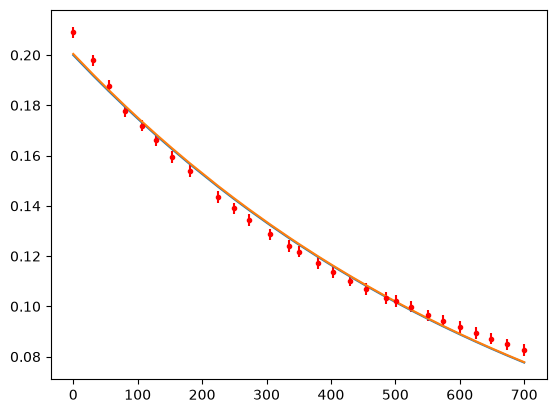

In [12]:
plt.errorbar(N_Perioden,nom(Amplitude),unp.std_devs(Amplitude), fmt="r.")
plt.plot(N_Perioden, Exponential_Function(N_Perioden, a_fit,delta_fit))
plt.plot(N_Perioden, Exponential_Function(N_Perioden, a_fit+d_a_fit,delta_fit))

7.00+-0.85e-4


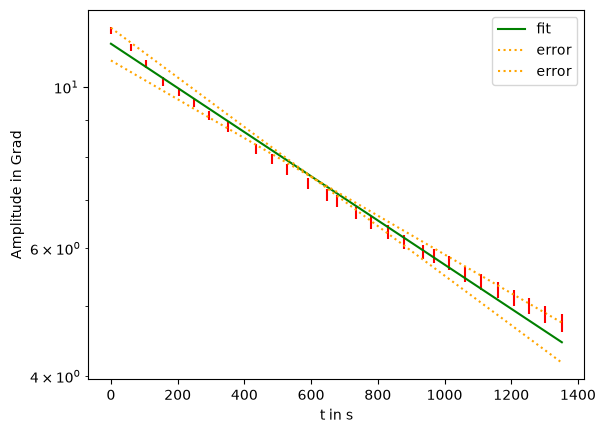

In [13]:
Amplitude_log = unp.log(unp.uarray(nom(Amplitude),unp.std_devs(Amplitude)))
Amplitude_log

Zeiten_Ampllitude = N_Perioden * T.nominal_value
def linear(x,m,b):
    return m * x + b
    
(m_fit,b_fit), cov = scipy.optimize.curve_fit(linear, Zeiten_Ampllitude, unp.nominal_values(Amplitude_log), sigma=unp.std_devs(Amplitude_log) *10 , absolute_sigma=True)
error = np.sqrt(np.diag(cov))
d_m_fit, d_b_fit = error
b_fit = unp.exp([ufloat(b_fit,d_b_fit)])[0]
d_b_fit = b_fit.std_dev
b_fit = b_fit.nominal_value
plt.semilogy(0,12)
plt.ylabel("Amplitude in Grad")

plt.errorbar(Zeiten_Ampllitude, unp.nominal_values(Amplitude)/ (2 * np.pi) * 360 , unp.std_devs(Amplitude) / (2 * np.pi) * 360 ,fmt="r,")
plt.plot(Zeiten_Ampllitude, Exponential_Function(Zeiten_Ampllitude,b_fit,m_fit)/ (2 * np.pi) * 360 , label="fit", color="green")
plt.plot(Zeiten_Ampllitude, Exponential_Function(Zeiten_Ampllitude,b_fit-d_b_fit,(m_fit + d_m_fit))/ (2 * np.pi) * 360 , label="error",color="orange",linestyle="dotted")
plt.plot(Zeiten_Ampllitude , Exponential_Function(Zeiten_Ampllitude,b_fit+d_b_fit,(m_fit - d_m_fit))/ (2 * np.pi) * 360 , label="error",color="orange",linestyle="dotted")
plt.xlabel("t in s")
ax = plt.gca()
#ax.yaxis.set_major_locator(LogLocator(base=10, numticks=150))
#ax.yaxis.set_minor_locator(LogLocator(base=10, subs=range(2, 100)))
plt.legend()
plt.savefig("Plot1.svg")

delta = -ufloat(m_fit, d_m_fit)
printu(delta)


# Erste Rechnung für g

In [14]:
Radius_Kugel = Durchmesser_Kugel / 2
T = T_ges / N
rho_F = 7.874 * 1000 # kg/m^3
rho_L =  1.2041 # kg / m^3
r_Faden = 0.1 * 10**(-3) # m
V_Kugel = 4/3 * np.pi * Radius_Kugel ** 3
m_Kugel = rho_F * V_Kugel
m_Faden = (L_oben / 1000) * rho_F * np.pi * r_Faden ** 2

print(m_Kugel)
print(m_Faden)
print(T)
print(L)

0.0570+/-0.0004
0.0002261+/-0.0000004
1.93017+/-0.00028
0.9257+/-0.0010


In [21]:
Korrektur_auftrieb = 2/5 * Radius_Kugel**2 / L**2 + rho_L/rho_F - 1/6 * m_Faden /m_Kugel


g_1 = (4 * np.pi**2 * L)/T**2 *(1+ Korrektur_auftrieb)
print(g_1)
print(Korrektur_auftrieb)




9.806+/-0.011
-0.000441+/-0.000005



# Zweite Rechnung für g


In [16]:
omega_0 = 2 * np.pi / T
print(omega_0)

# phi_0 berechnen

Auslenkung_max =  ufloat(0.182,0.001)
tan_phi = Auslenkung_max / Messhöhe
phi_0 = unp.arctan([tan_phi])[0] 
print(phi_0 / (2 * np.pi) * 360)

Korrektur_delta = delta**2 / omega_0**2
Korrektur_phi_0 = phi_0**2 / 8
printu(Korrektur_delta)
printu(Korrektur_phi_0)

3.2553+/-0.0005
11.98+/-0.07
4.62+-1.13e-8
5.46+-0.06e-3


In [17]:
g_2 = (4 * np.pi**2 * L)/T**2 *(1+ Korrektur_auftrieb + Korrektur_delta + Korrektur_phi_0)
print(g_2)


9.859+/-0.011


In [22]:
# Test der Korrektur entlang der Amplitude
print(phi_0 / (2 * np.pi) * 360,delta)
print(b_fit)
phi_0 = b_fit
def amplitude(t):    
    return Exponential_Function(t,phi_0,-delta)

def korrektur(amplitude):
    return amplitude**2 / 8
korrektur_amplitude = np.average(korrektur(amplitude(np.arange(0,T_ges.nominal_value))))
print("korrektur_amplitude" )
printu(korrektur_amplitude)
g_3 = (4 * np.pi**2 * L)/T**2 *(1+Korrektur_auftrieb + Korrektur_delta + korrektur_amplitude)
print(g_3)
printu(korrektur_amplitude)
printu(Korrektur_delta)
#plt.plot(x,amplitude(x) / (2 * np.pi) * 360)

11.470777831657257 0.00070+/-0.00009
0.20020284092719498
korrektur_amplitude
2.21+-0.18e-3
9.827+/-0.011
2.21+-0.18e-3
4.62+-1.13e-8


In [19]:

printu(g_1,digits=3)
printu(g_2,digits=3)
printu(g_3,digits=3)

g_4 = (4 * np.pi**2 * L)/T**2 *(1+Korrektur_auftrieb + Korrektur_delta)
printu(g_4,digits=3)


9.806+-0.011e+00
9.859+-0.011e+00
9.827+-0.011e+00
9.806+-0.011e+00


In [20]:

g_r = ufloat(9.80984, 2* 10**(-5))
def standardized_mean_difference(u1,u2):
    return (u1.nominal_value - u2.nominal_value)/(np.sqrt(u1.std_dev**2 + u2.std_dev**2)).__round__(2)

print(standardized_mean_difference(g_1,g_r).__round__(2))
print(standardized_mean_difference(g_2,g_r).__round__(2))
print(standardized_mean_difference(g_3,g_r).__round__(2))

-0.43
4.93
1.74
